# Water Possibility(음수) 가능 여부를 판단하기

1. 데이터 분석(EDA)
2. 결측 데이터 처리
3. 피처 엔지니어링
4. 머신러닝, 모델 평가, 테스트
5. 사용 학습기 : KNN, xgboost ML 모델을 만들고 성능 비교하기
6. GridSearchCV : 최적의 하이퍼 파라미터를 찾을 때 사용함

In [11]:
# warning 무시
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pylab as plt
# '-' 깨짐 해결 모듈
import matplotlib as mpl

import platform
from matplotlib import rc
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Linux':
    rc('font', family = 'NanumGothic')  # 또는 '나눔고딕'
    print('Linux system... font set to NanumGothic')
elif platform.system() == 'Windows':
    rc('font', family = 'Malgun Gothic')   # 또는 '맑은 고딕'
    print('Windows system... font set to Malgun Gothic')
else:
    print('Unknown system... sorry~~~~')

# 마이너스 깨짐 해결
mpl.rcParams["axes.unicode_minus"] = False


Linux system... font set to NanumGothic


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

데이터 출처 : https://www.kaggle.com/datasets/adityakadiwal/water-potability

데이터 설명
- ph: pH 1. 물(0~14).량
- Hardness비누를 침전시키는 물의 용량(mg/L)L.
- Solid총 용해 고형물(ppm)pm.
- Chloramin클로라민의 양(ppm).ppm.
- Sulfmg/L 단위로 용해된 황산염의 양.mg/L.
- Conducti물의 전기 전도도(단위: μS/cm).μS/cm.
- Organic_c유기 탄소의 양(ppm).in ppm.
- Trihalomeμg/L 단위의 트리할로메탄 양.in μg/L.
- Tu NTU 단위로 물의 발광 특성을 측정함.r in NTU.
- Po물이 인간이 섭취하기에 안전한지 여부를 나타냄
    - 마실 수 있는 -> 1
    - 마실 수 없는 -0potable -> 0

- 사용할 데이터는 사람이 마실 수 잇는 물인지 아닌지를 판단하는 데이터 입니다.

    - 독립변수(X) : ph ~ Turbidity
    - 종속변수(y) : potability

## 1. Data Load

In [13]:
water_df = pd.read_csv('datas_ml/water_potability.csv')
water_df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


## 2. 데이터 정보, 기술 통계 확인

In [14]:
water_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [15]:
# 기술 통계 확인하기
water_df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


## 3. 데이터 시각화

#### 모든 컬럼들의 데이터 분포 확인
- seaborn의 pairplot를 활용해 모든 컬럼들 간의 데이터 분포 확인하기
- hue = 'Potability'

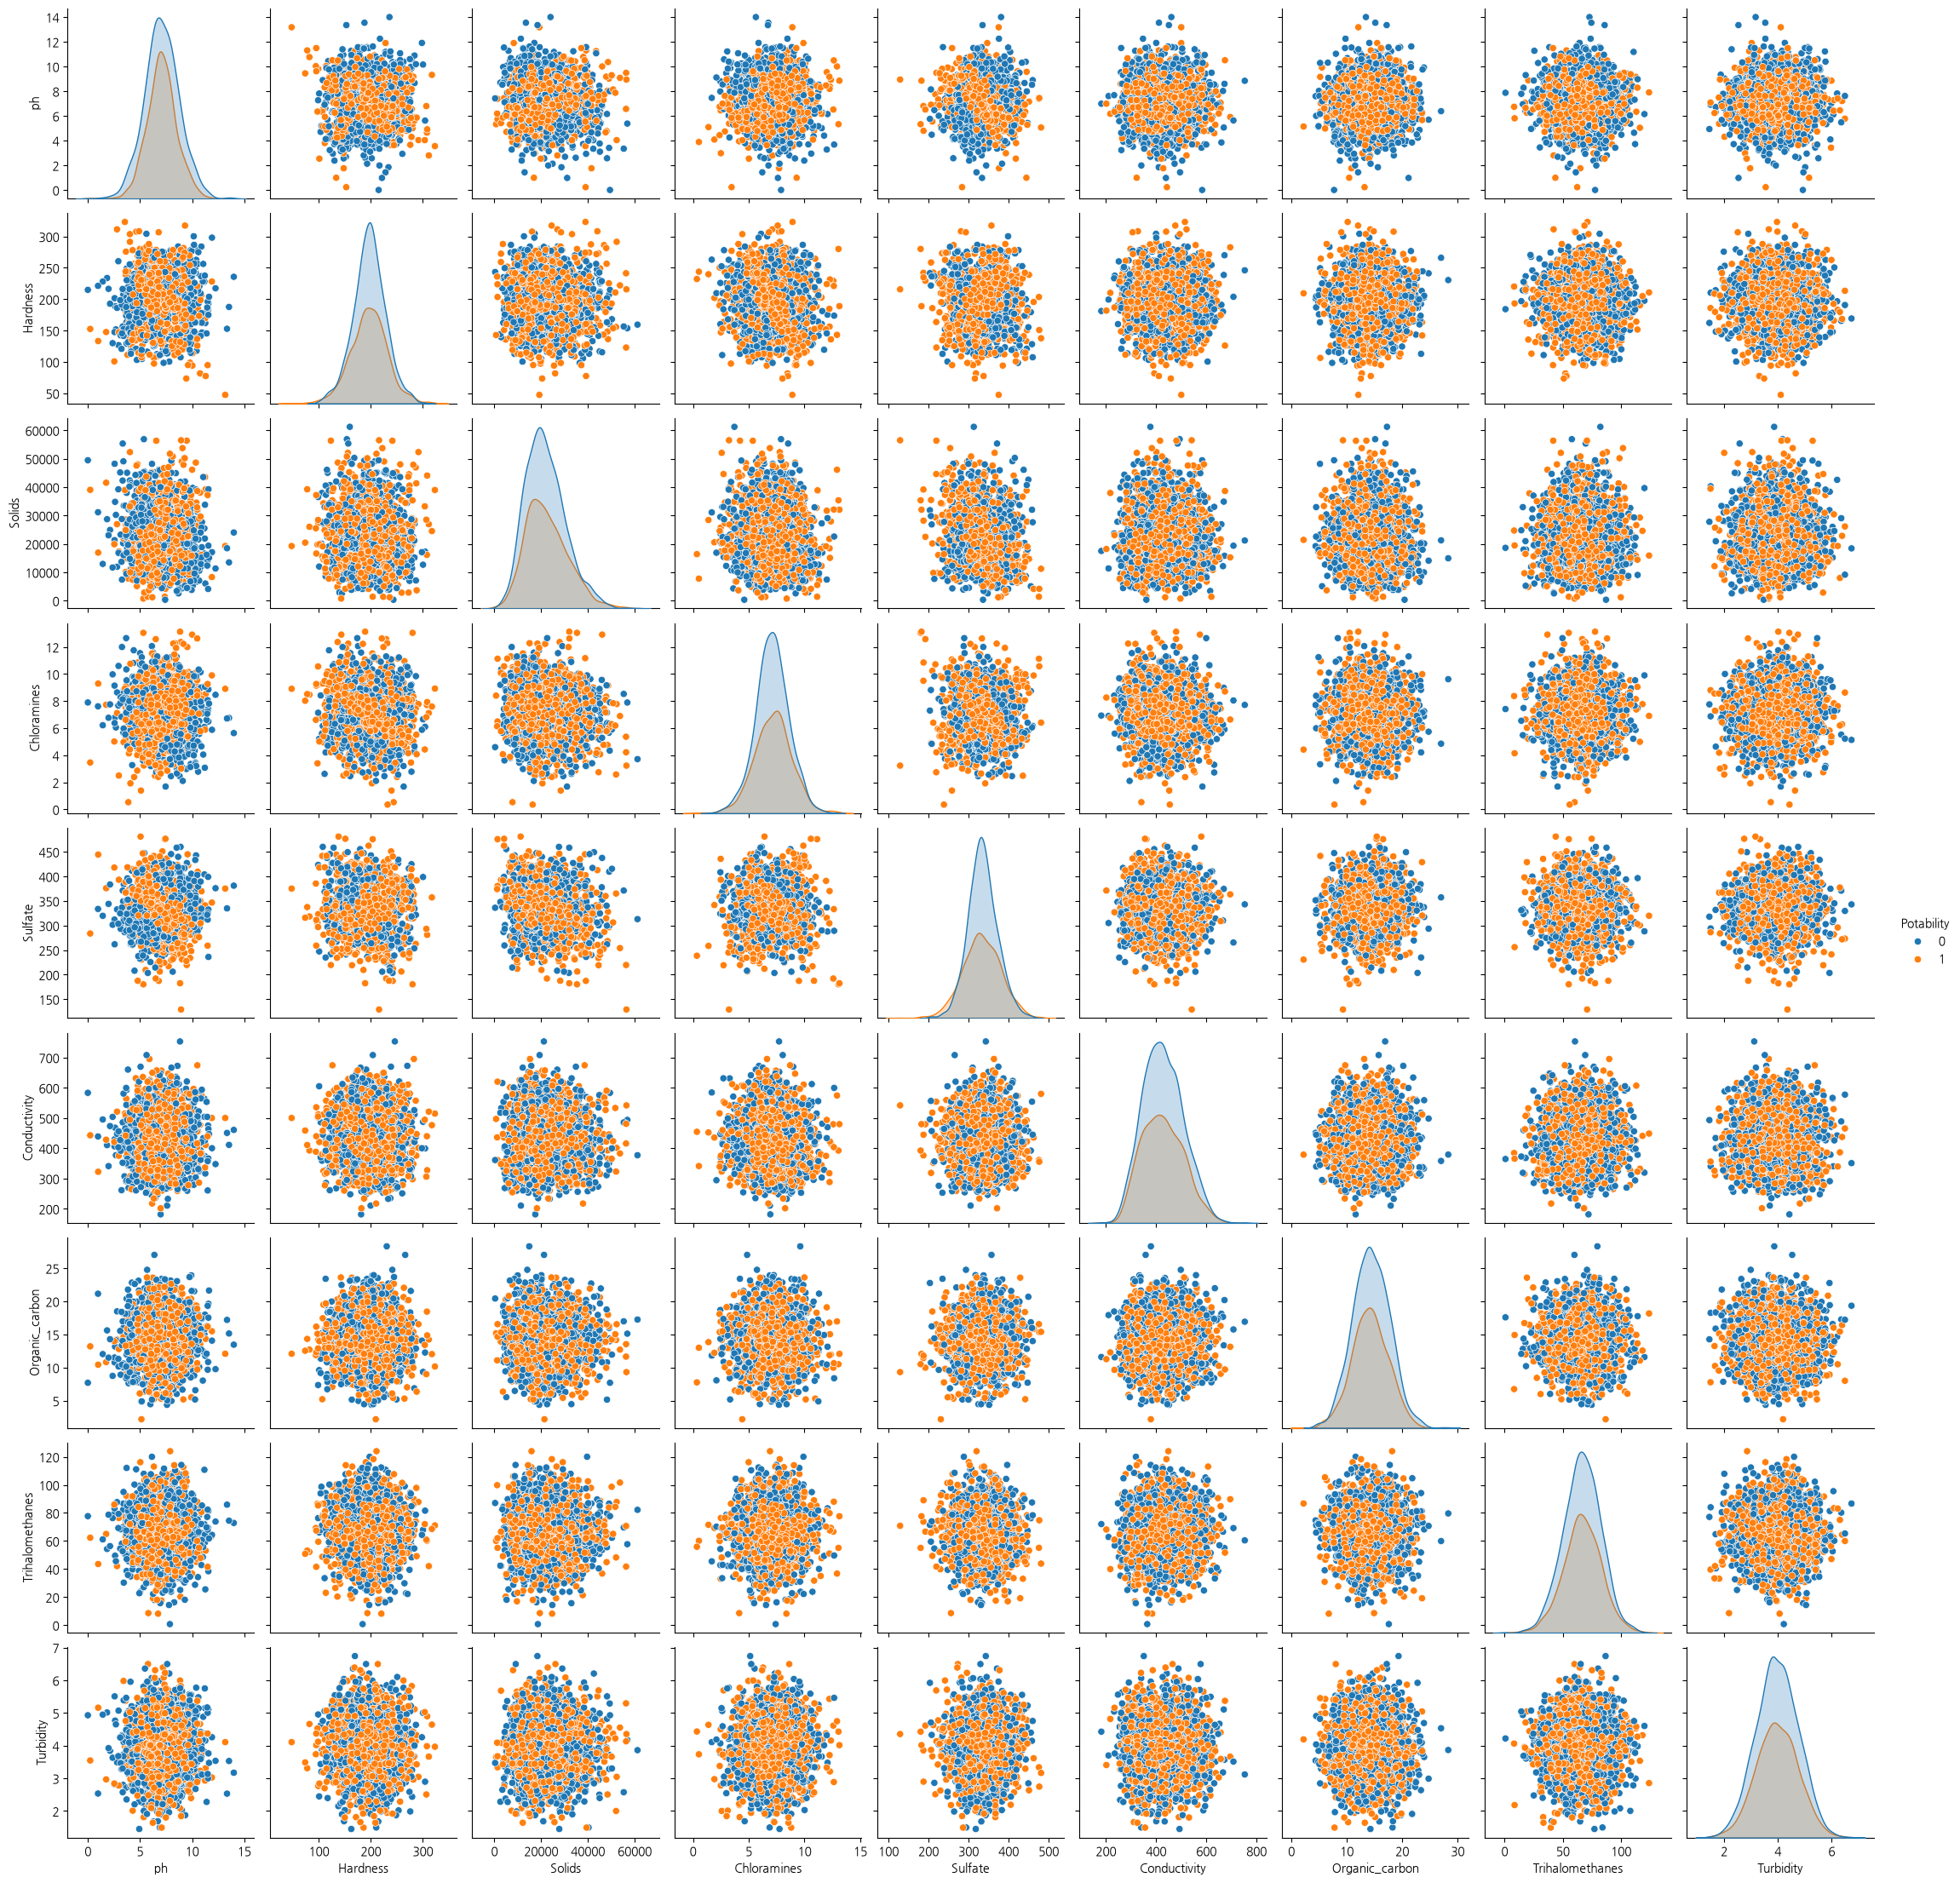

In [16]:
sns.pairplot(water_df, hue='Potability')
plt.show()

#### Potability 컬럼을 제외한 컬럼 이름만 리스트로 추출

In [17]:
col_names = water_df.select_dtypes(include=np.number).columns
col_names

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='str')

#### 데이터 분포, 관계 시각화
- 각 피처와 Potability와의 관계 확인
- histplot으로 그리기

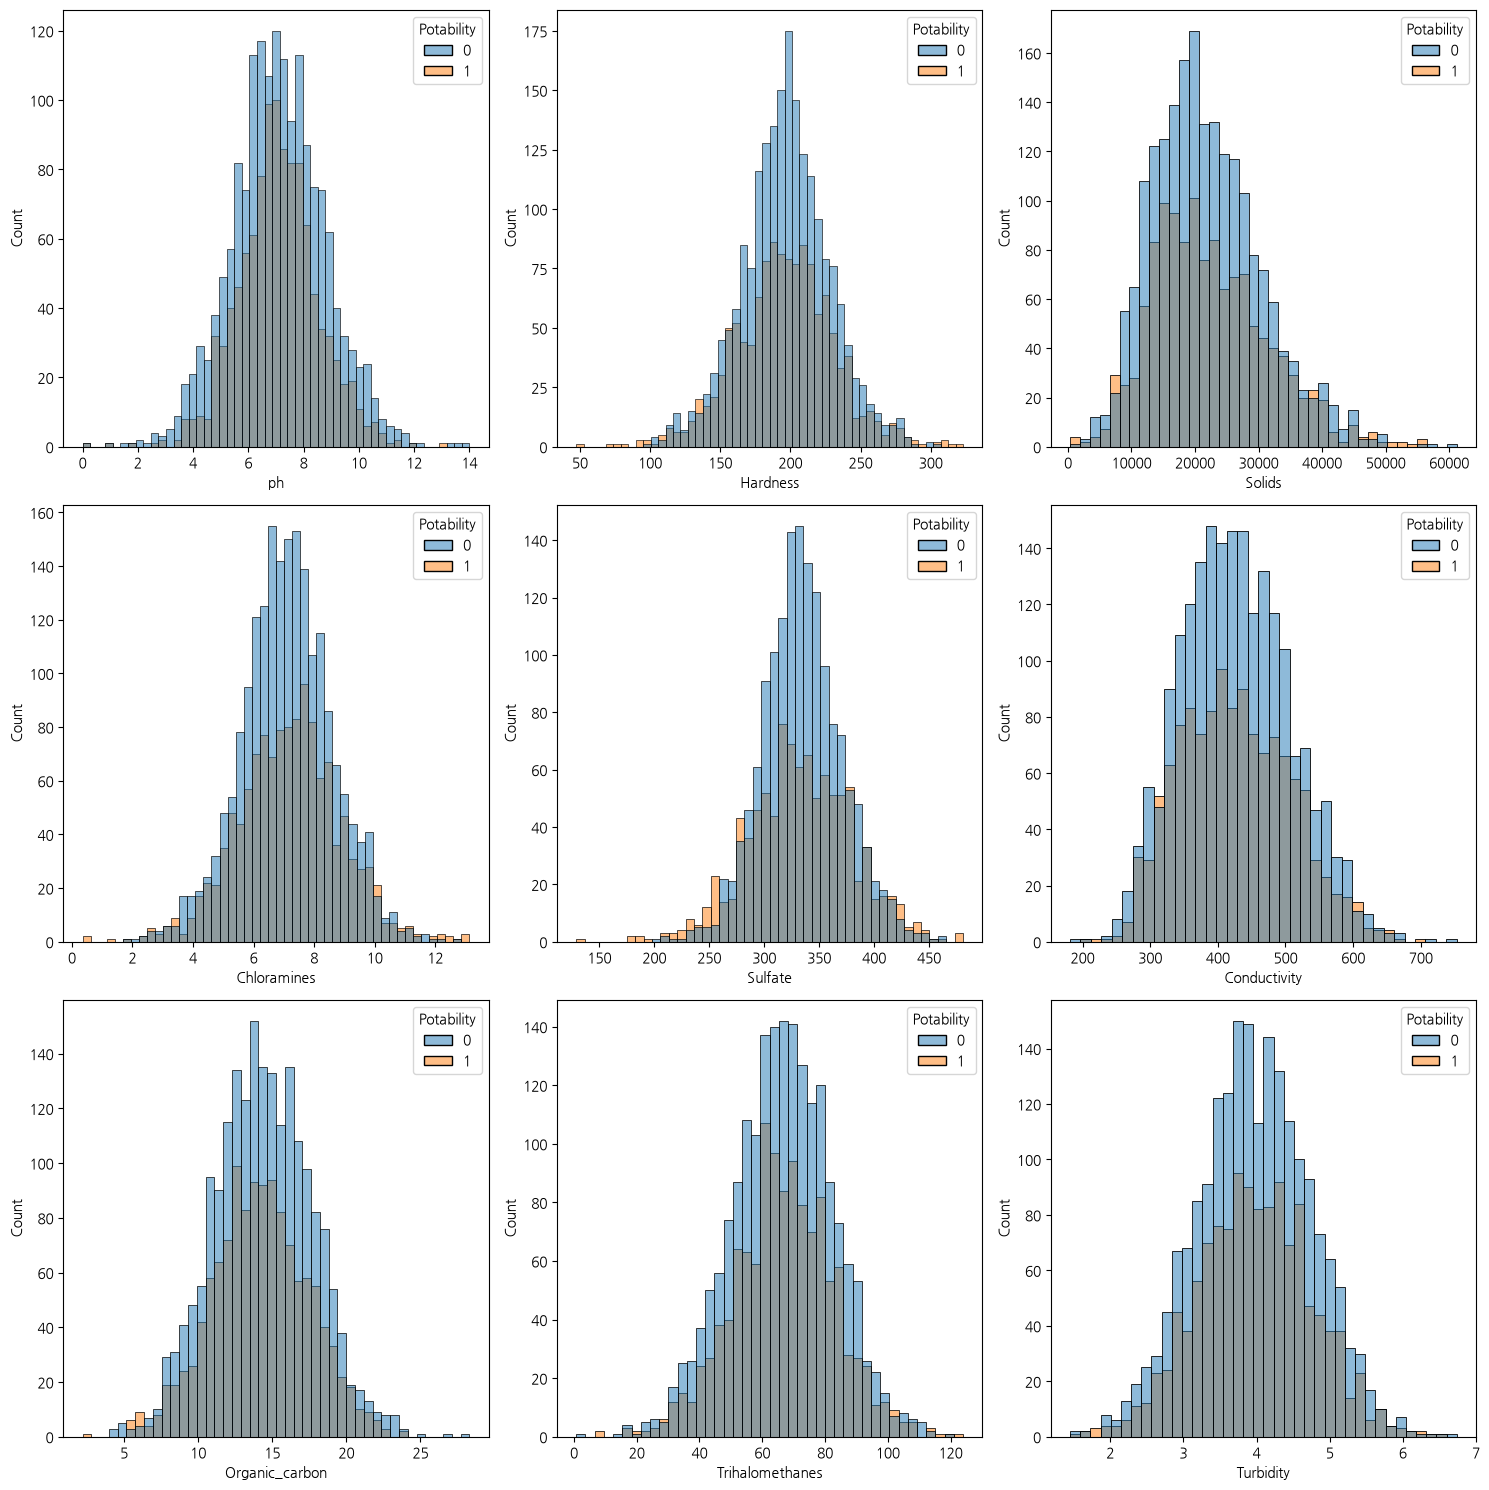

(9,)


In [18]:
# 1. 3x3 서브플롯 생성
nrows, ncols = 3, 3
figure, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 15))


axes = axes.flatten()


i = 0  
for col in water_df.columns:
    if col != 'Potability':  
        sns.histplot(data=water_df, x=col, hue='Potability', ax=axes[i])
        i += 1 

# 4. 레이아웃 조정 및 출력
plt.tight_layout()
plt.show()

print(axes.shape)

##### 범위, 분포, 이상치 시각화

(3, 3)
0 ph
1 Hardness
2 Solids
3 Chloramines
4 Sulfate
5 Conductivity
6 Organic_carbon
7 Trihalomethanes
8 Turbidity


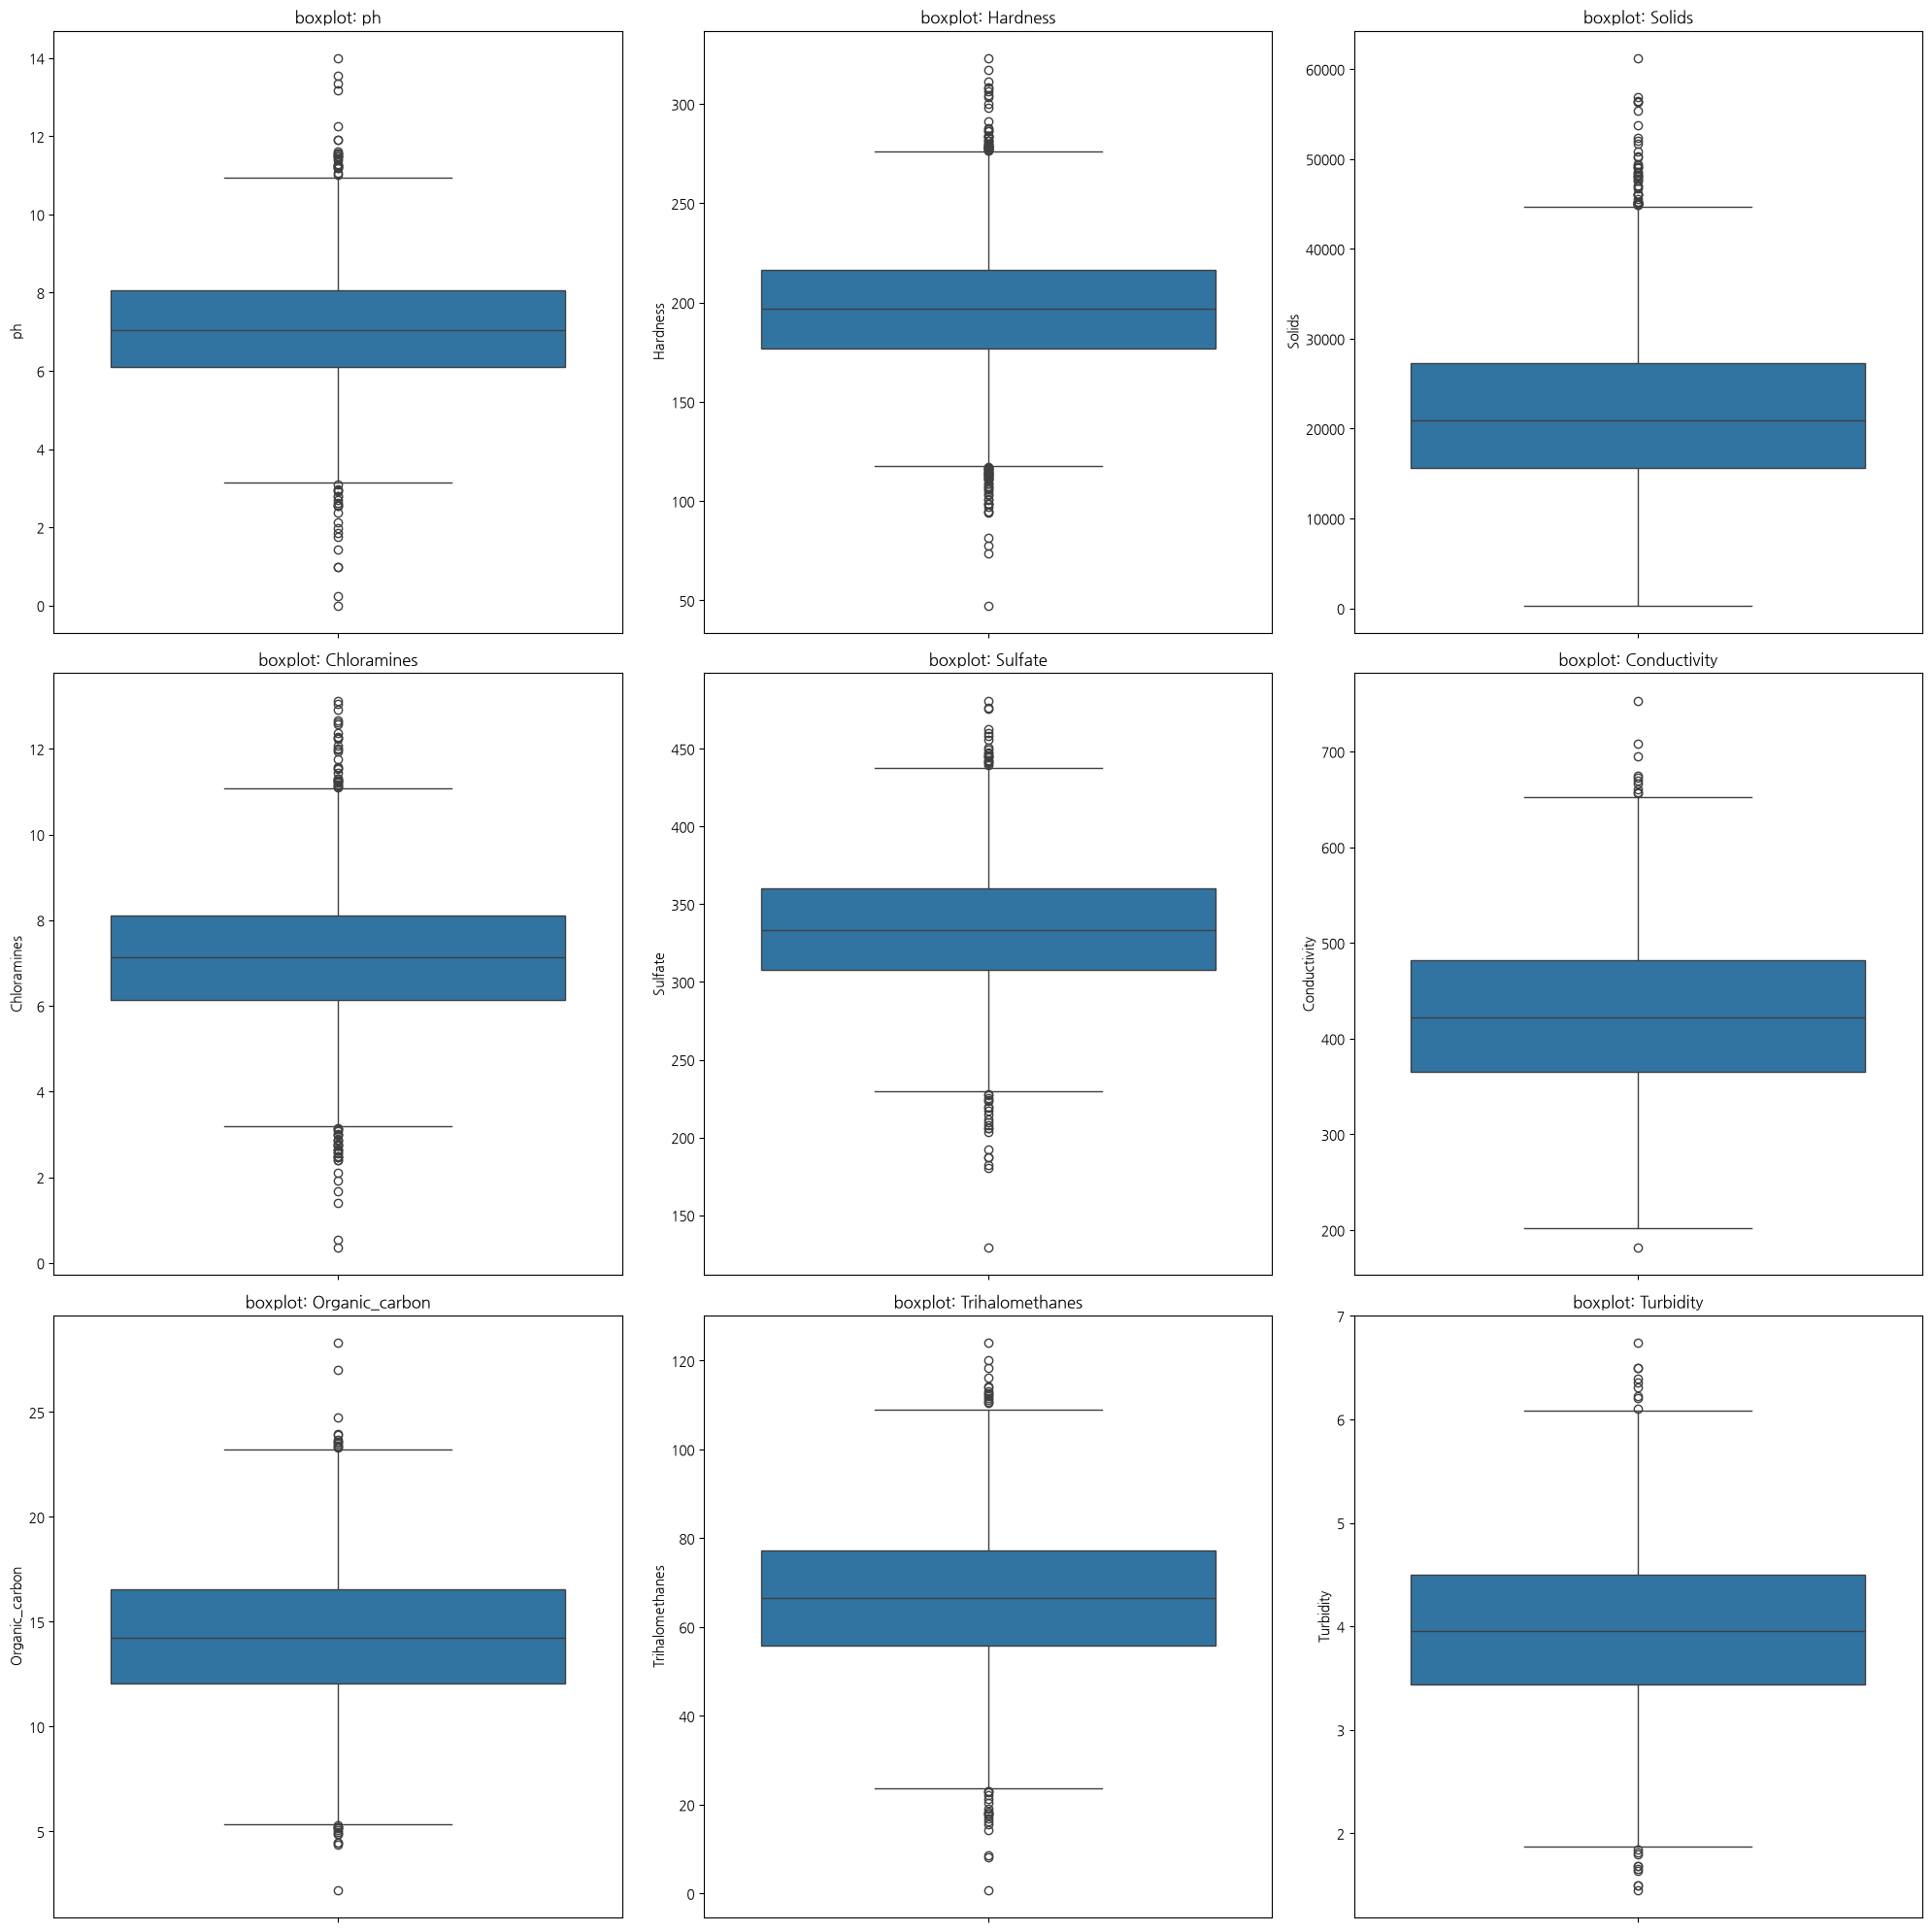

In [19]:
# 1. 수치형 컬럼 중 타겟 컬럼('Potability') 제외 (총 9개)
features = [col for col in col_names if col != 'Potability']

nrows, ncols = 3, 3
figure, axes = plt.subplots(nrows = nrows, ncols = ncols)
figure.set_size_inches(20,20)
print(axes.shape)
axes = axes.flatten()             # axs 2D -> 1D 1차원 벡터로 바꾼다.
for i, col in enumerate(features):
    print(i, col)
    ax = sns.boxplot(data=water_df, y=col, ax=axes[i])
    ax.set_title("boxplot: "+ col)
plt.tight_layout() # 겹치는 거 방지

In [20]:
# 수치형 데이터 확인
temp_df = water_df[col_names]
temp_df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


#### 각 피처들의 상관계수 시각화

In [21]:
corr_df = water_df.corr()

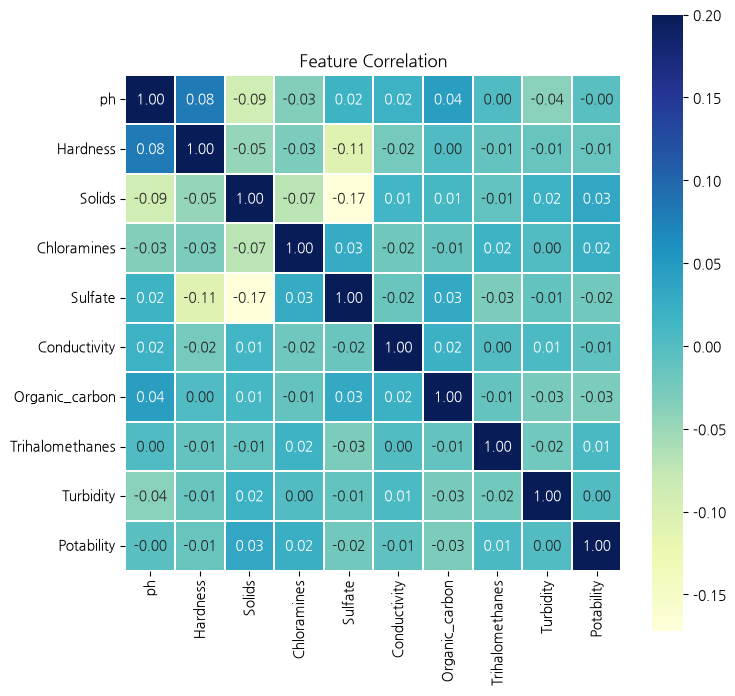

In [22]:
# 피처들간의 상관관계 살펴보기
plt.figure(figsize=(8, 8));
sns.heatmap(corr_df,
            vmax=0.2,
            linewidths=0.01,
            square=True,
            annot=True,
            fmt = '.2f', # annot의 출력 소숫점 자리 지정
            annot_kws={"size": 10},  # annot 글자크기
            cmap='YlGnBu');
plt.title('Feature Correlation');

#### 4. Data Preprocess
- 각 컬럼 별로 결측 데이터의 갯수가 몇 개인지 확인하기

In [23]:
water_df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [24]:
water_df.isnull().sum().sort_values()

Hardness             0
Solids               0
Chloramines          0
Conductivity         0
Organic_carbon       0
Turbidity            0
Potability           0
Trihalomethanes    162
ph                 491
Sulfate            781
dtype: int64

In [25]:
# nan이 하나라도 있는 index(행) 삭제
drop_row = water_df.dropna()

In [26]:
drop_row.shape

(2011, 10)

In [27]:
drop_row.info()

<class 'pandas.DataFrame'>
Index: 2011 entries, 3 to 3271
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2011 non-null   float64
 1   Hardness         2011 non-null   float64
 2   Solids           2011 non-null   float64
 3   Chloramines      2011 non-null   float64
 4   Sulfate          2011 non-null   float64
 5   Conductivity     2011 non-null   float64
 6   Organic_carbon   2011 non-null   float64
 7   Trihalomethanes  2011 non-null   float64
 8   Turbidity        2011 non-null   float64
 9   Potability       2011 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 172.8 KB


#### 5. Data Split
- drop_row 데이터 프레임에서 독립변수 X 와 종속변수 y로 나누기

In [28]:
X = drop_row.drop(['Potability'], axis=1)

In [29]:
X.shape

(2011, 9)

In [30]:
y = drop_row['Potability']

In [31]:
y.shape

(2011,)

In [32]:
drop_row.info()

<class 'pandas.DataFrame'>
Index: 2011 entries, 3 to 3271
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2011 non-null   float64
 1   Hardness         2011 non-null   float64
 2   Solids           2011 non-null   float64
 3   Chloramines      2011 non-null   float64
 4   Sulfate          2011 non-null   float64
 5   Conductivity     2011 non-null   float64
 6   Organic_carbon   2011 non-null   float64
 7   Trihalomethanes  2011 non-null   float64
 8   Turbidity        2011 non-null   float64
 9   Potability       2011 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 172.8 KB


#### 6. 피처 스케일링
- 데이터의 특성을 파악하여 피처 스케일 방법을 선택하고 독립변수에 적용하기
- 이상치가 많다고 판단하여 RobustScaler 사용

In [33]:
from sklearn.preprocessing import RobustScaler

X_scaled = RobustScaler()
X_scaled = X_scaled.fit_transform(X)

In [34]:
X_scaled[:5]

array([[ 0.65680483,  0.43282692,  0.09379373,  0.46448723,  0.47688378,
        -0.52025154,  0.90251278,  1.58391031,  0.61665097],
       [ 1.05179243, -0.40533748, -0.25542893, -0.30307355, -0.42741347,
        -0.21647915, -0.60622354, -1.61880978,  0.0997875 ],
       [-0.73511455, -0.22366198,  0.67564865,  0.20344828, -0.10742795,
        -1.23592751, -1.29904724, -0.54473938, -1.31477791],
       [ 1.6282047 ,  1.28173434,  0.67573759,  0.1874853 ,  1.1882697 ,
        -1.20840881, -0.11676465,  0.84639096, -1.20903279],
       [ 0.81933308,  0.15542278, -0.62777472, -1.30954823, -0.55944876,
         0.44213393, -0.42952973, -0.17544605,  0.40442813]])

In [35]:
x_cols = X.columns
x_cols

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity'],
      dtype='str')

In [36]:
X_scaled_df = pd.DataFrame(X_scaled, columns=x_cols)
X_scaled_df.head(3)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,0.656805,0.432827,0.093794,0.464487,0.476884,-0.520252,0.902513,1.583910,0.616651
1,1.051792,-0.405337,-0.255429,-0.303074,-0.427413,-0.216479,-0.606224,-1.618810,0.099787
2,-0.735115,-0.223662,0.675649,0.203448,-0.107428,-1.235928,-1.299047,-0.544739,-1.314778


#### 7. 데이터를 Train, Test로 나누기

<Axes: xlabel='Potability', ylabel='count'>

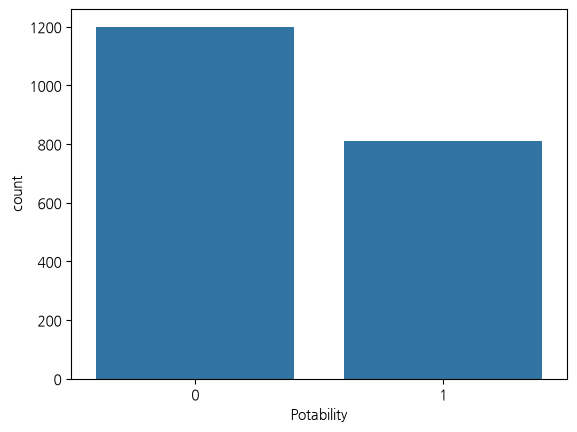

In [37]:
# 'Potability' 컬럼 값 비율 확인
sns.countplot(x=y)

- y 값을 균일하게 분할
- test data size 0.2
- 실행할 때마다 분할이 재현되도록 random_state 2024

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
train_X, test_X, train_y, test_y = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=2024
    )

In [40]:
train_X.shape, train_y.shape

((1608, 9), (1608,))

In [41]:
test_X.shape, test_y.shape

((403, 9), (403,))

##### KNN ML 모델 만들기 및 평가

In [42]:
from sklearn.neighbors import KNeighborsClassifier

In [43]:
classifier = KNeighborsClassifier()
classifier.fit(train_X, train_y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [44]:
classifier.n_neighbors
y_pred = classifier.predict(test_X)

In [45]:
from sklearn.metrics import confusion_matrix, accuracy_score

confusion_matrix(test_y, y_pred)

array([[171,  69],
       [112,  51]])

In [46]:
from sklearn.metrics import classification_report, accuracy_score

# y_test: 실제 라벨, y_pred: 모델 예측 라벨
print("정확도:", accuracy_score(test_y, y_pred))
print("\n[정밀도, 재현율, F1-score 요약 보고서]")
print(classification_report(test_y, y_pred))

정확도: 0.5508684863523573

[정밀도, 재현율, F1-score 요약 보고서]
              precision    recall  f1-score   support

           0       0.60      0.71      0.65       240
           1       0.42      0.31      0.36       163

    accuracy                           0.55       403
   macro avg       0.51      0.51      0.51       403
weighted avg       0.53      0.55      0.54       403



#### GridSearchCV활용 Best Hyper Parameter 찾기
- 다음의 파라미터에 대해서 KNN 모델의 베스트 파라미터를 찾아보세요.

- n_neighbors : [2, 4, 6, 8, 10],
- p : [1, 2]
- cv : 3

In [47]:
from sklearn.model_selection import GridSearchCV

In [48]:
params = {
    'n_neighbors': [2, 4, 6, 8, 10],
    'p': [1, 2]
}

In [49]:
params

{'n_neighbors': [2, 4, 6, 8, 10], 'p': [1, 2]}

In [50]:
grid_cv = GridSearchCV(
    classifier,
    param_grid= params,
    cv = 3,
    scoring='recall',
    n_jobs=-1 
)

In [51]:
# GridSearchCV 학습 수행
grid_cv.fit(train_X, train_y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [2, 4, ...], 'p': [1, 2]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting,

#### 모델 평가

In [52]:
print(f"Best score of paramter search is: {grid_cv.best_score_:.4f}")

Best score of paramter search is: 0.1975


In [53]:
grid_cv.best_params_

{'n_neighbors': 6, 'p': 1}

In [54]:
print("Best parameter of best score is")
print(f"\t n_neighbors: {grid_cv.best_params_['n_neighbors']}")
print(f"\t p: {grid_cv.best_params_['p']}")

Best parameter of best score is
	 n_neighbors: 6
	 p: 1


#### 예측 및 평가

In [55]:
test_pred = grid_cv.predict(test_X)

In [56]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(test_y, test_pred)
print(roc_auc)

0.5233895705521472


In [57]:
from sklearn.metrics import accuracy_score

test_acc = roc_auc_score(test_y, test_pred)
print(f"test accuracy is {test_acc:.4f}")

test accuracy is 0.5234


In [58]:
# 분류 성능 레포트
from sklearn.metrics import classification_report

print(classification_report(test_y, test_pred))

              precision    recall  f1-score   support

           0       0.61      0.88      0.72       240
           1       0.48      0.17      0.25       163

    accuracy                           0.59       403
   macro avg       0.55      0.52      0.49       403
weighted avg       0.56      0.59      0.53       403



#### xgboost 모델 만들기 및 평가

In [59]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier()
xgb_clf.fit(train_X, train_y)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [60]:
train_pred = xgb_clf.predict(train_X)
test_pred = xgb_clf.predict(test_X)

train_acc = accuracy_score(train_y, train_pred)
test_acc = accuracy_score(test_y, test_pred)

print(f"train accuracy is {train_acc:.4f}")
print(f"test accuracy is {test_acc:.4f}")

train accuracy is 1.0000
test accuracy is 0.6700


In [61]:
# classification_report() 결과 출력
print(classification_report(test_y, test_pred))

              precision    recall  f1-score   support

           0       0.69      0.80      0.74       240
           1       0.62      0.48      0.54       163

    accuracy                           0.67       403
   macro avg       0.66      0.64      0.64       403
weighted avg       0.66      0.67      0.66       403



#### 10. ML 모델의 feature importance 시각화

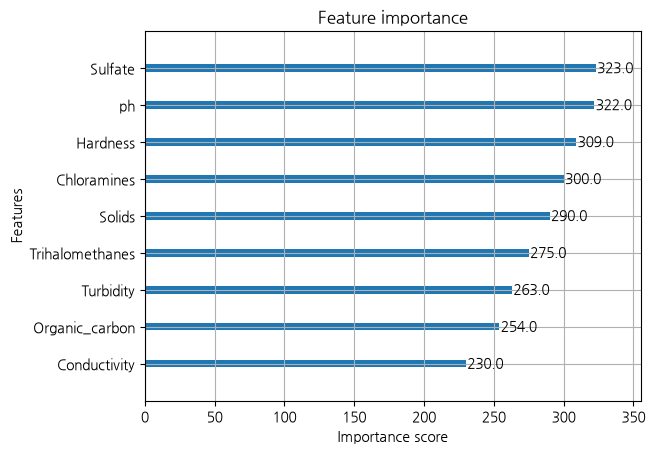

In [62]:
#xgboost의 강력한 기능 Feature Importance 확인
from xgboost import plot_importance
from matplotlib import pyplot

plot_importance(xgb_clf)
pyplot.show()

#### 11. 최적의 하이퍼 파라미터 찾기
- xgboost 모델이 과적합인 것 같다.
- xgboost 활용해 베스트 하이퍼 파리터 찾기
- GridSearchCV를 활용해 베스트 하이퍼 파라미터를 찾는 과정을 기술하고 모델을 평가해 보세요.

In [63]:
print(f"Best CV Score: {grid_cv.best_score_:.4f}")
print("Best Parameters:", grid_cv.best_params_)

Best CV Score: 0.1975
Best Parameters: {'n_neighbors': 6, 'p': 1}


In [64]:
from sklearn.metrics import accuracy_score, classification_report

# 1. 최적의 모델(best_estimator_)로 예측
best_xgb = grid_cv.best_estimator_

train_pred = best_xgb.predict(train_X)
test_pred = best_xgb.predict(test_X)

In [65]:
# 훈련 / 테스트 정확도 계산
train_acc = accuracy_score(train_y, train_pred)
test_acc = accuracy_score(test_y, test_pred)

In [66]:
print(f"train accuracy is {train_acc:.4f}")
print(f"test accuracy is {test_acc:.4f}")

train accuracy is 0.6685
test accuracy is 0.5906


In [67]:
print(classification_report(test_y, test_pred))

              precision    recall  f1-score   support

           0       0.61      0.88      0.72       240
           1       0.48      0.17      0.25       163

    accuracy                           0.59       403
   macro avg       0.55      0.52      0.49       403
weighted avg       0.56      0.59      0.53       403

